In [ ]:
from importlib.resources import files
from nsbutils.plotting import plot_surf
from neuromodes import EigenSolver
from neuromodes.io import fetch_example_surf
import numpy as np
import matplotlib.pyplot as plt
from lapy import Solver
from lapy.diffgeo import compute_geodesic_f
from lapy.heat import diffusion
from scipy.sparse.linalg import splu
from potpourri3d import MeshVectorHeatSolver

In [10]:
n_parcels = 20
n_iterations = 30
n_modes = 500

In [2]:
# # Load cortical surface mesh
# surf, medmask = fetch_example_surf()

# actually no let's try the sphere
surf = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_sphere.surf.gii'
solver = EigenSolver(surf)

In [ ]:
solver.solve(n_modes)

In [ ]:
def make_cvt_parcellation(
    geometry,
    n_parcels,
    emodes,
    evals,
    n_iterations = 10
):
    m = 1.0

    verts = geometry.v
    n_verts = len(verts)

    seeds = np.random.choice(n_verts, size=n_parcels, replace=False)
    # TODO: farthest point sampling to get faster convergence
    
    # Precompute LU for heat
    solver = Solver(geometry, lump=True)
    hmat = solver.mass + m * geometry.avg_edge_length()**2 * solver.stiffness
    lu = splu(hmat)

    # Spectral Embedding Time Step (Longer time for smooth centroids)
    # Approximate expected area of a single parcel
    total_area = geometry.area()
    parcel_area = total_area / n_parcels
    t_spectral = parcel_area / np.pi # t ~ r^2
    
    # Pre-compute the k-dimensional spectral embedding for all vertices
    verts_heat = np.exp(-evals[None, :] * t_spectral) * emodes

    # initialise arrays
    is_moved = np.ones(n_parcels, dtype=bool)
    all_parcellations = np.empty((n_verts, n_iterations), dtype=np.int32)
    sources = np.zeros((n_verts, n_parcels), dtype=np.float64)

    # Voronoi iteration
    for i in range(n_iterations):
        is_moved[:] = False 
        
        # Heat diffusion from current seeds
        sources = np.zeros((n_verts, n_parcels), dtype=np.float64)
        for k, vert in enumerate(seeds):
            sources[vert, k] = 1.0
        heat = lu.solve(sources)  # shape (n_verts, n_parcels)
        dists = compute_geodesic_f(geometry, heat)  # TODO: unwrap, as mass/stiffness is unchanged across iterations

        # Build parcellation as nearest seed
        parcellation = np.argmin(dists, axis=1)

        for k in range(n_parcels):
            parcel_verts = np.where(parcellation == k)[0]

            # Calculate centroid in k-dimensional spectral space
            centroid = np.mean(verts_heat[parcel_verts], axis=0)

            # Find vertex closest to centroid in spectral space
            spectral_dists_to_centroid = np.linalg.norm(verts_heat[parcel_verts] - centroid[None, :], axis=1)
            
            # Map local minimum index back to global vertex index
            new_seed_local = np.argmin(spectral_dists_to_centroid)
            new_seed = parcel_verts[new_seed_local] 
            
            if new_seed != seeds[k]:
                is_moved[k] = True
                seeds[k] = new_seed

        print(f"Iteration {i+1}: Moved {np.sum(is_moved)} seeds")
        all_parcellations[:, i] = parcellation
        
        # Early stopping if converged
        if not np.any(is_moved):
            print("Converged early!")
            break

    return all_parcellations

In [85]:
parcellation = make_cvt_parcellation(solver.geometry, n_parcels,
                                     solver.emodes, solver.evals,
                                     n_iterations)

Iteration 1: Moved 20 seeds
Iteration 2: Moved 19 seeds
Iteration 3: Moved 17 seeds
Iteration 4: Moved 17 seeds
Iteration 5: Moved 13 seeds
Iteration 6: Moved 10 seeds
Iteration 7: Moved 10 seeds
Iteration 8: Moved 8 seeds
Iteration 9: Moved 6 seeds
Iteration 10: Moved 4 seeds
Iteration 11: Moved 7 seeds
Iteration 12: Moved 8 seeds
Iteration 13: Moved 5 seeds
Iteration 14: Moved 4 seeds
Iteration 15: Moved 4 seeds
Iteration 16: Moved 4 seeds
Iteration 17: Moved 7 seeds
Iteration 18: Moved 3 seeds
Iteration 19: Moved 4 seeds
Iteration 20: Moved 4 seeds
Iteration 21: Moved 5 seeds
Iteration 22: Moved 5 seeds
Iteration 23: Moved 3 seeds
Iteration 24: Moved 0 seeds
Converged early!


In [ ]:
# boxplot of parcel areas over iterations
idx = [0, 1, 5, 23]
areas = solver.mass.sum(axis=1).A1
parc_areas = np.zeros((n_parcels, idx[-1]+1))
for i in range(n_parcels):
    for j in range(idx[-1]+1):
        mask = parcellation == i
        parc_areas[i, j] = areas[mask[:, j]].sum()

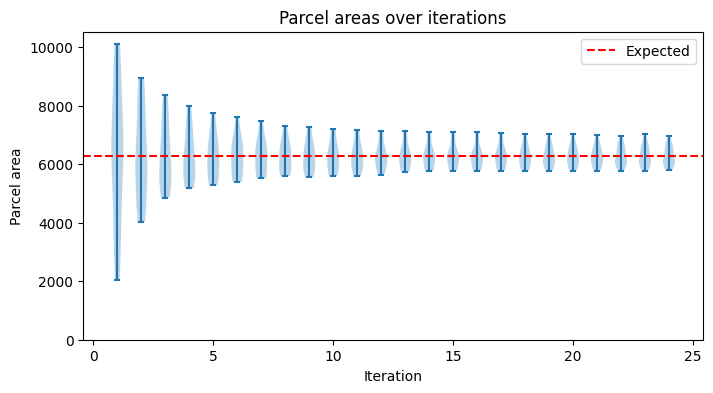

In [97]:
plt.violinplot(parc_areas)
plt.axhline(solver.geometry.area() / n_parcels, color='red', linestyle='--', label='Expected')
plt.xlabel('Iteration')
plt.ylabel('Parcel area')
plt.title('Parcel areas over iterations')
plt.legend()
plt.ylim(bottom=0)
plt.gcf().set_size_inches(8, 4)
plt.show()

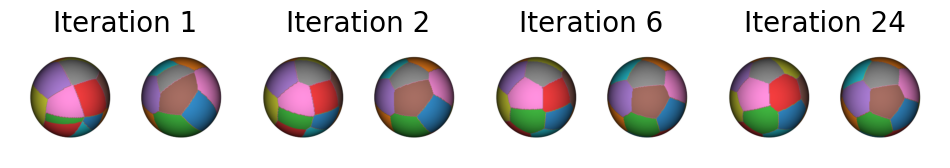

In [ ]:
plot_surf(surf, parcellation[:, idx], labels=[f'Iteration {i+1}' for i in idx], cmap='tab10')

### Cortex + medial wall

In [26]:
fslr32k, medmask = fetch_example_surf()
solver_cort = EigenSolver(fslr32k)

In [ ]:
solver_cort.solve(n_modes)

In [111]:
parcellation_cort = make_cvt_parcellation(solver_cort.geometry, n_parcels,
                                          solver_cort.emodes, solver_cort.evals,
                                          n_iterations)

Iteration 1: Moved 20 seeds
Iteration 2: Moved 20 seeds
Iteration 3: Moved 19 seeds
Iteration 4: Moved 18 seeds
Iteration 5: Moved 19 seeds
Iteration 6: Moved 17 seeds
Iteration 7: Moved 14 seeds
Iteration 8: Moved 6 seeds
Iteration 9: Moved 5 seeds
Iteration 10: Moved 5 seeds
Iteration 11: Moved 2 seeds
Iteration 12: Moved 3 seeds
Iteration 13: Moved 3 seeds
Iteration 14: Moved 5 seeds
Iteration 15: Moved 4 seeds
Iteration 16: Moved 4 seeds
Iteration 17: Moved 4 seeds
Iteration 18: Moved 3 seeds
Iteration 19: Moved 2 seeds
Iteration 20: Moved 1 seeds
Iteration 21: Moved 2 seeds
Iteration 22: Moved 4 seeds
Iteration 23: Moved 4 seeds
Iteration 24: Moved 2 seeds
Iteration 25: Moved 3 seeds
Iteration 26: Moved 2 seeds
Iteration 27: Moved 3 seeds
Iteration 28: Moved 2 seeds
Iteration 29: Moved 4 seeds
Iteration 30: Moved 3 seeds


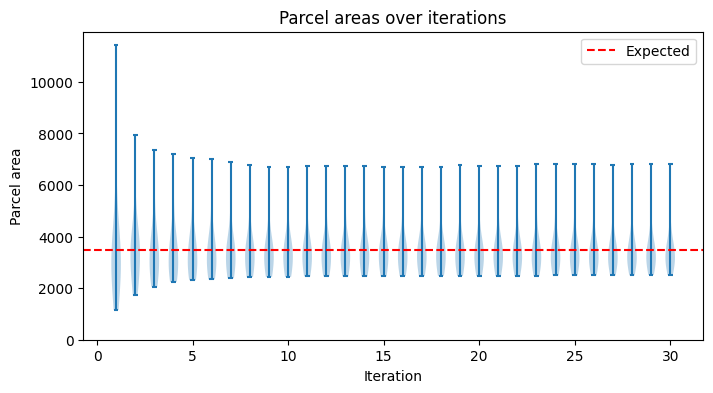

In [114]:
idx = [0, 1, 5, 29]
areas = solver_cort.mass.sum(axis=1).A1
parc_areas = np.zeros((n_parcels, idx[-1]+1))
for i in range(n_parcels):
    for j in range(idx[-1]+1):
        mask = parcellation_cort == i
        parc_areas[i, j] = areas[mask[:, j]].sum()

plt.violinplot(parc_areas)
plt.axhline(solver_cort.geometry.area() / n_parcels, color='red', linestyle='--', label='Expected')
plt.xlabel('Iteration')
plt.ylabel('Parcel area')
plt.title('Parcel areas over iterations')
plt.legend()
plt.ylim(bottom=0)
plt.gcf().set_size_inches(8, 4)
plt.show()

In [29]:
surfpath_cort = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'

In [ ]:
plot_surf(surfpath_cort, parcellation_cort[:, idx], labels=[f'Iteration {i+1}' for i in idx], cmap='tab10')

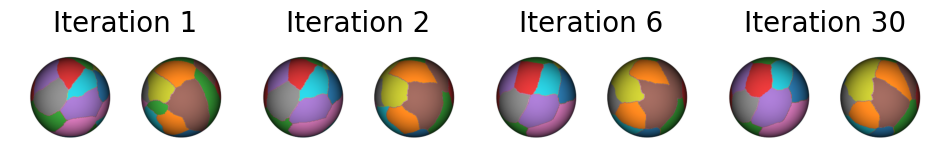

In [116]:
# plot cortical parcellation on sphere
plot_surf(surf, parcellation_cort[:, idx], labels=[f'Iteration {i+1}' for i in idx], cmap='tab10')

### Heat method visualisation

In [14]:
# plot geodesic distances to random seeds
n_parcels = 5
seeds = np.random.default_rng(0).choice(solver.n_verts, size=n_parcels, replace=False)

# turn into n_parcels-length list of lists for diffusion function
sources = [[seed] for seed in seeds]
heat = diffusion(solver.geometry, sources, m=1.0)
print(heat.shape)
dists = compute_geodesic_f(solver.geometry, heat)

(32492, 5)


Seed 0: vertex 20694
Seed 1: vertex 16606
Seed 2: vertex 8765
Seed 3: vertex 10001
Seed 4: vertex 27635


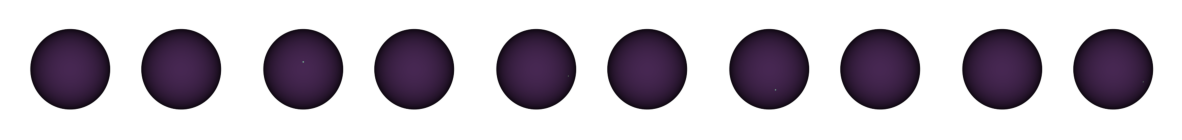

In [15]:
# plot seeds
seed_maps = np.zeros((solver.n_verts, n_parcels))
for k, seed in enumerate(seeds):
    seed_maps[seed, k] = 1.0
    print(f"Seed {k}: vertex {seed}")
plot_surf(surf, seed_maps, cmap='turbo')

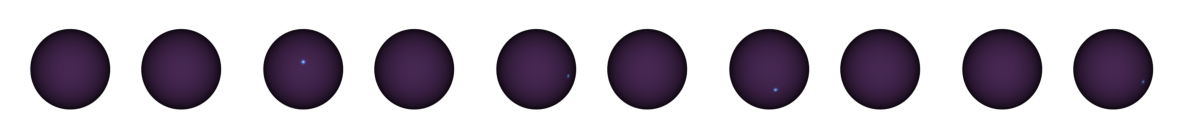

In [19]:
# plot heat
plot_surf(surf, heat, cmap='turbo')

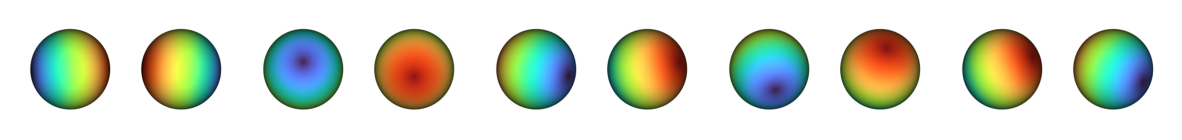

In [20]:
# plot distance maps
plot_surf(surf, dists, cmap='turbo')

### Logarithmic map

In [5]:
pp3d = MeshVectorHeatSolver(solver.geometry.v, solver.geometry.t)

In [23]:
logmap = pp3d.compute_log_map(10001, strategy='AffineLocal')

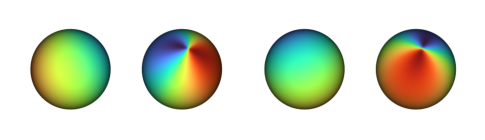

In [24]:
plot_surf(surf, logmap, cmap='turbo')

In [27]:
pp3d_cort = MeshVectorHeatSolver(solver_cort.geometry.v, solver_cort.geometry.t)

In [47]:
init_vert = 10001
logmap_cort = pp3d_cort.compute_log_map(init_vert, strategy='AffineLocal')

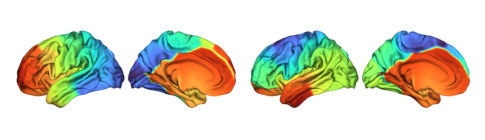

In [31]:
plot_surf(surfpath_cort, logmap_cort, cmap='turbo')

In [54]:
# visualise init_vert via geodesic distance
dists_init_vert = compute_geodesic_f(solver_cort.geometry, diffusion(solver_cort.geometry, [init_vert]))

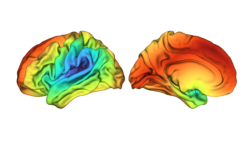

In [55]:
plot_surf(surfpath_cort, dists_init_vert, cmap='turbo')

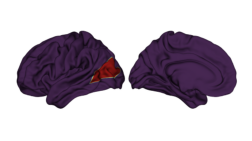

In [53]:
# select a patch of cortex to take the Karcher mean on
patch_verts = np.arange(15000, 16000)
patch_verts_map = np.zeros(solver_cort.n_verts)
patch_verts_map[patch_verts] = 1.0
plot_surf(surfpath_cort, patch_verts_map, cmap='turbo')

In [45]:
update_vector = 1/len(patch_verts) * logmap_cort[patch_verts, :].sum(axis=0)

In [58]:
# move init_vert in direction of update_vector and visualise
transported_field = pp3d_cort.transport_tangent_vector(init_vert, update_vector)

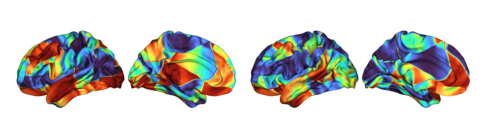

In [59]:
plot_surf(surfpath_cort, transported_field, cmap='turbo')